In [ ]:
import pandas as pd

url = "https://www.kaggle.com/api/v1/datasets/download/ivansher/nasa-nearest-earth-objects-1910-2024"

!wget -q "$url" -O /content/asteroids.zip
!unzip -o /content/asteroids.zip -d /content/asteroids

import os
print(os.listdir('/content/asteroids'))

Archive:  /content/asteroids.zip
  inflating: /content/asteroids/nearest-earth-objects(1910-2024).csv  
['nearest-earth-objects(1910-2024).csv']


In [ ]:
import pandas as pd

file_path = "/content/asteroids/nearest-earth-objects(1910-2024).csv"

df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

display(df.head())

Dataset shape: (338199, 9)

Columns:
['neo_id', 'name', 'absolute_magnitude', 'estimated_diameter_min', 'estimated_diameter_max', 'orbiting_body', 'relative_velocity', 'miss_distance', 'is_hazardous']


,neo_id,name,absolute_magnitude,estimated_diameter_min,estimated_diameter_max,orbiting_body,relative_velocity,miss_distance,is_hazardous
0,2162117,162117 (1998 SD15),19.14,0.394962,0.883161,Earth,71745.401048,5.814362e+07,False
1,2349507,349507 (2008 QY),18.50,0.530341,1.185878,Earth,109949.757148,5.580105e+07,True
2,2455415,455415 (2003 GA),21.45,0.136319,0.304818,Earth,24865.506798,6.720689e+07,False
3,3132126,(2002 PB),20.63,0.198863,0.444672,Earth,78890.076805,3.039644e+07,False
4,3557844,(2011 DW),22.70,0.076658,0.171412,Earth,56036.519484,6.311863e+07,False


In [ ]:
# Check missing values
print("Missing values:")
print(df.isnull().sum())

# Keep only useful ML features
features = [
    'absolute_magnitude',
    'estimated_diameter_min',
    'estimated_diameter_max',
    'relative_velocity',
    'miss_distance'
]

X = df[features].copy()
y = df['is_hazardous'].astype(int)

# Fill missing values with median
X = X.fillna(X.median())

print("\nFeatures:", features)
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

Missing values:
neo_id                     0
name                       0
absolute_magnitude        28
estimated_diameter_min    28
estimated_diameter_max    28
orbiting_body              0
relative_velocity          0
miss_distance              0
is_hazardous               0
dtype: int64

Features: ['absolute_magnitude', 'estimated_diameter_min', 'estimated_diameter_max', 'relative_velocity', 'miss_distance']
X shape: (338199, 5)
y shape: (338199,)

Target distribution:
is_hazardous
0    295037
1     43162
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

# Train Random Forest
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

print("\nTraining model...")
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\n===== MODEL PERFORMANCE =====")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Training samples: 270559
Testing samples: 67640

Training model...

===== MODEL PERFORMANCE =====
Accuracy : 0.9186
Precision: 0.7331
Recall   : 0.5692
F1 Score : 0.6408

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.97      0.95     59008
           1       0.73      0.57      0.64      8632

    accuracy                           0.92     67640
   macro avg       0.84      0.77      0.80     67640
weighted avg       0.91      0.92      0.91     67640



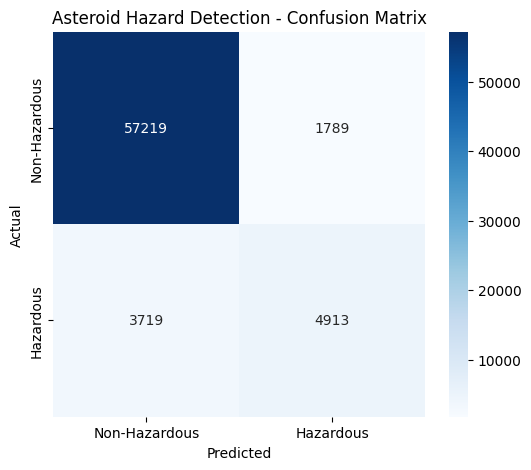

Feature Importance:


,Feature,Importance
0,absolute_magnitude,0.277648
1,estimated_diameter_min,0.194343
3,relative_velocity,0.190714
2,estimated_diameter_max,0.169166
4,miss_distance,0.168129


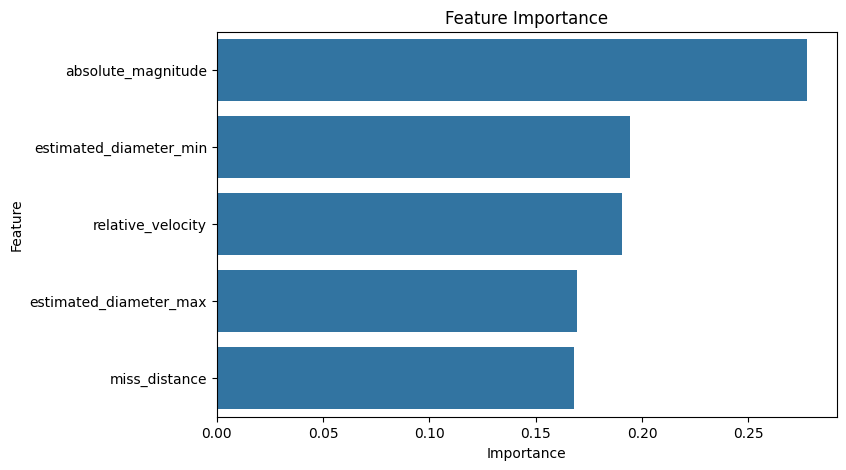

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Hazardous", "Hazardous"],
    yticklabels=["Non-Hazardous", "Hazardous"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Asteroid Hazard Detection - Confusion Matrix")
plt.show()


# Feature Importance
importance = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)

print("Feature Importance:")
display(importance)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")
plt.show()

In [ ]:
import joblib

joblib.dump(model, "/content/asteroid_model.pkl")

print("✅ Model saved successfully!")

✅ Model saved successfully!


In [ ]:
from google.colab import files

files.download("/content/asteroid_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>